## Mini RAG — retrieval + generation (Ollama, local)

Ce notebook couvre les deux briques du mini RAG : la recherche vectorielle
(section 1, ci-dessous) puis la generation. On branche un LLM **local** (Ollama,
deja utilise dans `04_exploration/test_llm_iconographie_ollama.ipynb`) sur le
top-k retourne par la recherche vectorielle, pour qu'il redige une reponse plutot que
de se contenter de la liste de voisins.

**Pourquoi Ollama et pas une API payante** : pas de cle/abonnement API necessaire, tout
tourne en local avec les modeles deja telecharges.

**Pourquoi ca devrait mieux marcher que le test precedent** : le bilan de
`test_llm_iconographie_ollama.ipynb` concluait que les modeles locaux (llava, llama3.2)
etaient inutilisables pour l'iconographie ovidienne — mais ce test les interrogeait **a
froid** : reconnaitre un theme depuis les pixels seuls, ou le decrire de memoire, sans
aucune base de reference. Ici le LLM n'a plus a *percevoir* ou *se souvenir* — la
recherche vectorielle a deja fait ce travail et fournit le theme, le score de similarite
et les metadonnees d'edition en texte. Le LLM n'a plus qu'a **synthetiser des faits deja
recuperes**, une tache nettement plus facile pour un petit modele local.

### 1. Retrieval (recherche visuelle + hybride)

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import torch
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

from rag_utils import (
    charger_e5,
    charger_index,
    charger_siglip,
    contexte_depuis_resultats,
    embed_image,
    embed_texte,
    libelle_resultat,
    rechercher,
    rechercher_hybride,
)

RACINE = Path("../../").resolve()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)


In [ ]:
DOSSIER_VECTOR_DB = RACINE / "data" / "vector_bases"
index, X_index, X_index_meta = charger_index(DOSSIER_VECTOR_DB)

print(f"Index unifie : {len(index)} illustrations "
      f"({(index['source'] == 'bible').sum()} Bibles, {(index['source'] == 'ovide').sum()} Ovide), "
      f"embeddings {X_index.shape}")

modele_e5 = charger_e5()
print("Modele e5 charge")


### 1bis. Modele texte-texte pour les metadonnees (e5)

SigLIP n'est entraine qu'a comparer image<->texte, pas texte<->texte : reutiliser SigLIP pour indexer les metadonnees donne de mauvais resultats (verifie empiriquement). `multilingual-e5-small` est concu pour ca.

In [ ]:
processor, model_siglip = charger_siglip(DEVICE)
print("SigLIP complet (texte + image) charge")


### Recherche hybride (visuel + metadonnees)

In [ ]:
def afficher_grille(resultats, titre=""):
    n = len(resultats)
    fig, axes = plt.subplots(1, n, figsize=(n * 2.2, 2.7))
    axes = [axes] if n == 1 else axes
    for i, (ax, (_, row)) in enumerate(zip(axes, resultats.iterrows()), 1):
        ax.imshow(Image.open(row["chemin"]).convert("RGB"))
        ax.set_title(f"#{i} [{row['source']}] {libelle_resultat(row)}\n{row['similarite']:.3f}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(titre, fontsize=10)
    plt.tight_layout()
    plt.show()


def afficher_avec_requete(chemin_requete, resultats, titre=""):
    n = len(resultats)
    fig, axes = plt.subplots(1, n + 1, figsize=((n + 1) * 2.2, 2.7))
    axes[0].imshow(Image.open(chemin_requete).convert("RGB"))
    axes[0].set_title("requete", fontsize=8)
    axes[0].set_xticks([]); axes[0].set_yticks([])
    for i, (ax, (_, row)) in enumerate(zip(axes[1:], resultats.iterrows()), 1):
        ax.imshow(Image.open(row["chemin"]).convert("RGB"))
        ax.set_title(f"#{i} [{row['source']}] {libelle_resultat(row)}\n{row['similarite']:.3f}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(titre, fontsize=10)
    plt.tight_layout()
    plt.show()

**A propos des scores** : les similarites texte->image ci-dessus (~0.10-0.16) sont
beaucoup plus basses en valeur absolue que les similarites image->image plus bas
(~0.9+). C'est une caracteristique connue de l'espace SigLIP (entraine avec une perte
sigmoid, pas un softmax contrastif comme CLIP) — ce qui compte est le **classement
relatif** des resultats, pas la valeur absolue du score.

### Demo — requetes texte (francais)

Meme test en francais, pour objectiver l'ecart avant de decider s'il faut traduire
les requetes.

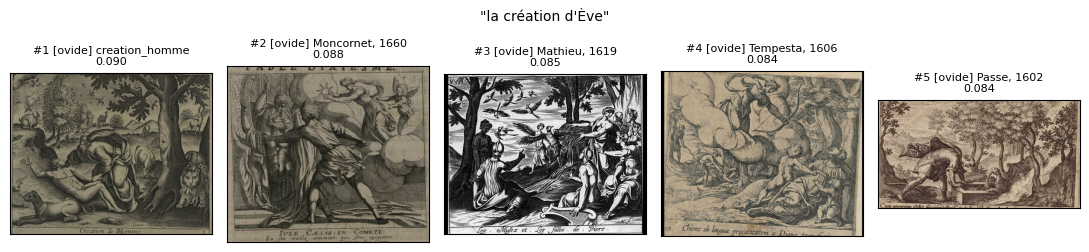

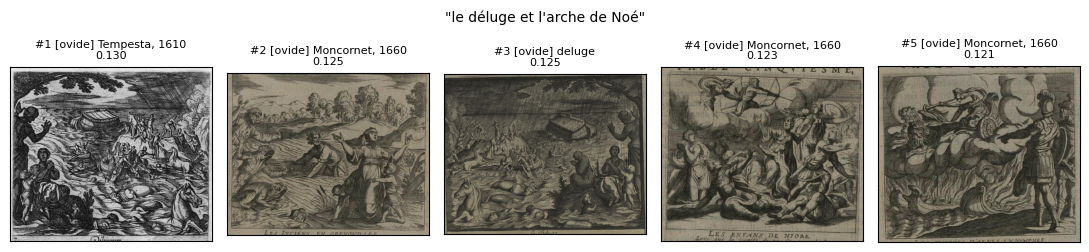

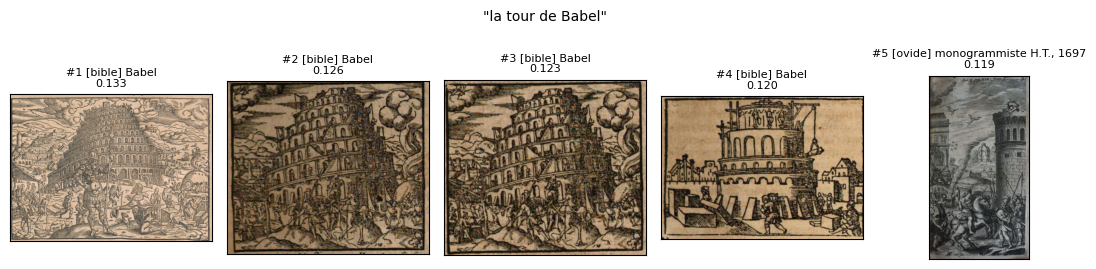

In [7]:
REQUETES_FR = [
    "la création d'Ève",
    "le déluge et l'arche de Noé",
    "la tour de Babel",
]

for requete in REQUETES_FR:
    v = embed_texte(requete)
    resultats = rechercher(v, k=5)
    afficher_grille(resultats, titre=f'"{requete}"')

**Constat** : "la tour de Babel" reste correcte, mais "la création d'Ève" tombe
a cote (aucun resultat du theme `Creation EVE` dans le top 5) et le deluge est moins
net qu'en anglais. `google/siglip-base-patch16-224` est entraine sur WebLI,
majoritairement anglophone.

**Mitige depuis par la recherche hybride** (voir plus bas) : `rechercher_hybride()`
combine ce signal visuel avec un second index texte (`multilingual-e5-small`,
entraine multilingue) par Reciprocal Rank Fusion. Dans l'appli finale (`app_rag.py`),
toute requete texte passe par cette recherche hybride, pas par SigLIP seul — la
limite ci-dessus reste vraie pour la brique visuelle isolee, mais n'empeche plus le
francais de bien fonctionner en pratique (voir les requetes de test dans
`docs/mini_rag_iconographique.md`).

### Demo — requete image (sanity check leave-one-out)

On reprend une illustration deja presente dans l'index, on la retire de l'index, on
la reencode comme une requete "fraiche", et on verifie que ses plus proches voisines
restantes partagent bien le meme theme. Sert a valider que le pipeline d'encodage
requete est bien coherent avec celui utilise pour construire la base.

In [ ]:
ligne_test = index.iloc[0]
index_sans_requete = index.drop(index.index[0]).reset_index(drop=True)
X_sans_requete = np.delete(X_index, 0, axis=0)

v_img = embed_image(ligne_test["chemin"], processor, model_siglip, DEVICE)
sims = cosine_similarity(v_img.reshape(1, -1), X_sans_requete)[0]
ordre = sims.argsort()[::-1][:5]
resultats_loo = index_sans_requete.iloc[ordre].copy()
resultats_loo["similarite"] = sims[ordre]

print(f"Requete : {Path(ligne_test['chemin']).name}  (theme attendu : {ligne_test['theme']})")
afficher_avec_requete(ligne_test["chemin"], resultats_loo, titre="Sanity check (leave-one-out)")

### Demo — requete image hors base (planches Salomon)

Memes pages "themes connus" utilisees dans `vector_base.ipynb` pour la comparaison
CLIP/DINOv2/SigLIP.

In [ ]:
OVIDE_DIR = RACINE / "data" / "editions_ovide" / "segmentees" / "bois_salomon_rouille_lyon1557"

for page in ["f003", "f012", "f056"]:
    correspondances = sorted(OVIDE_DIR.glob(f"salomon_{page}_*.jpg"))
    if not correspondances:
        print(f"  ! aucune image trouvee pour {page}")
        continue
    chemin_requete = correspondances[0]
    v = embed_image(chemin_requete, processor, model_siglip, DEVICE)
    resultats = rechercher(v, index, X_index, k=5)
    afficher_avec_requete(chemin_requete, resultats, titre=chemin_requete.name)

### 2. Config Ollama

Verifie qu'Ollama tourne (`ollama serve`) et que `llama3.2` est bien present
parmi les modeles deja telecharges.

**Mise a jour** : le ralentissement CPU constate au premier essai (~1,5 tok/s malgre
une RTX 5090 disponible) venait d'un paquet Ollama tiers (snap communautaire, version
0.24.0, sans support GPU pour cette architecture recente). Remplace par l'installation
officielle (`curl -fsSL https://ollama.com/install.sh | sh`, version 0.32.1) : `ollama ps`
affiche desormais `100% GPU` et la generation tourne a **~265 tokens/seconde** (mesure
directe, contre ~1,5 tok/s avant) — le plafond de tokens et le long timeout ci-dessous
ne sont plus necessaires.

In [10]:
OLLAMA_URL = "http://localhost:11434"
MODELE_TEXTE = "llama3.2"

try:
    r = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5)
    noms_modeles = [m["name"] for m in r.json().get("models", [])]
    OLLAMA_DISPONIBLE = any(MODELE_TEXTE in nom for nom in noms_modeles)
    print("Ollama en ligne — modeles disponibles :", noms_modeles)
    if not OLLAMA_DISPONIBLE:
        print(f"! {MODELE_TEXTE} non trouve — lance : ollama pull {MODELE_TEXTE}")
except Exception as e:
    print(f"Ollama indisponible ({e}) — lance : ollama serve")
    OLLAMA_DISPONIBLE = False

Ollama en ligne — modeles disponibles : ['qwen3.6:latest', 'qwen2.5vl:latest', 'moondream:latest', 'llava:7b', 'llama3.2-vision:latest', 'llama3.2:latest']


### 3. Contexte texte a partir des resultats retrieval

In [ ]:
# contexte_depuis_resultats() importee depuis rag_utils.py


### 4. Prompt et appel Ollama

In [12]:
PROMPT_SYSTEME = """Tu es un expert en iconographie de la Renaissance europeenne (16e-17e s.),
specialise dans les editions illustrees des Metamorphoses d'Ovide et les Bibles
illustrees (MDZ/BSB).

Pour chaque illustration retrouvee par recherche vectorielle (SigLIP, similarite
cosinus), les champs disponibles varient : score de similarite toujours present,
theme precis pour une minorite seulement (la plupart des illustrations Ovide ne
sont pas cataloguees planche par planche), et pour les Ovide d'autres metadonnees
souvent presentes (titre de l'edition, ville, annee, graveur, technique, famille
iconographique). Le theme n'est qu'un champ parmi d'autres, pas un prerequis de
pertinence : juge chaque illustration a partir de TOUT ce qui est fourni pour
elle, jamais seulement de la presence ou de l'absence du champ theme — une
illustration sans theme mais avec un bon score de similarite et des metadonnees
coherentes (meme famille iconographique, meme periode...) reste pertinente. Un
meme numero de famille iconographique entre deux illustrations signifie qu'elles
appartiennent au meme cycle de gravures (copie ou modele partage).

Tu n'as PAS vu les images : ne decris jamais un contenu visuel (scene,
personnage, composition, decor) que tu n'as pas recu par ecrit — ni en
affirmant qu'un personnage y figure, ni en affirmant qu'il en est absent.
Chaque illustration listee ci-dessous a SES PROPRES champs, distincts des
autres illustrations de la liste : ne reporte jamais un theme, un personnage
ou une metadonnee d'une illustration vers une autre de la meme liste, meme si
elles se ressemblent ou partagent le meme sujet de requete.

Attention : le Deluge biblique (Noe, l'arche) et le Deluge ovidien (Jupiter,
Deucalion, Pyrrha) sont deux recits differents — mais ne cite ces noms que
s'ils apparaissent litteralement dans les metadonnees ci-dessous, jamais de
memoire.

Consignes de reponse :
- Appuie-toi uniquement sur les informations fournies ci-dessous, tous champs
  confondus (pas seulement le theme).
- Utilise tous les champs informatifs disponibles dans ta reponse.
- Indique explicitement les numeros d'illustration qui appuient ta reponse.
- Recompte soigneusement avant de conclure — ne generalise pas sur une impression
  globale."""


def generer_reponse_rag(requete, resultats):
    if not OLLAMA_DISPONIBLE:
        return "[generation desactivee : Ollama indisponible ou modele non trouve]"
    contexte = contexte_depuis_resultats(resultats)
    message_utilisateur = f"""Requete : {requete}

Illustrations retrouvees par recherche vectorielle (SigLIP, similarite cosinus) :
{contexte}

Reponds en 5-8 phrases maximum."""
    r = requests.post(
        f"{OLLAMA_URL}/api/chat",
        json={
            "model": MODELE_TEXTE,
            "messages": [
                {"role": "system", "content": PROMPT_SYSTEME},
                {"role": "user", "content": message_utilisateur},
            ],
            "stream": False,
            # GPU (RTX 5090, ~265 tok/s) — plus besoin de plafonner court
            "options": {"num_predict": 500},
        },
        timeout=60,
    )
    r.raise_for_status()
    return r.json()["message"]["content"]

### 5. Demo bout en bout

`rag_texte()` et `rag_image()` enchainent recherche + generation + affichage.

In [ ]:
def rag_texte(requete, k=5):
    v = embed_texte(requete, processor, model_siglip, DEVICE)
    resultats = rechercher(v, index, X_index, k=k)
    afficher_grille(resultats, titre=f'"{requete}"')
    reponse = generer_reponse_rag(f'"{requete}"', resultats)
    print(reponse)
    return resultats, reponse


def rag_image(chemin_requete, k=5):
    v = embed_image(chemin_requete, processor, model_siglip, DEVICE)
    resultats = rechercher(v, index, X_index, k=k)
    afficher_avec_requete(chemin_requete, resultats, titre=Path(chemin_requete).name)
    reponse = generer_reponse_rag(
        f"une illustration ({Path(chemin_requete).name}), theme inconnu a identifier a partir des voisins ci-dessous",
        resultats,
    )
    print(reponse)
    return resultats, reponse

#### Requetes texte (themes bien representes cote Bibles)

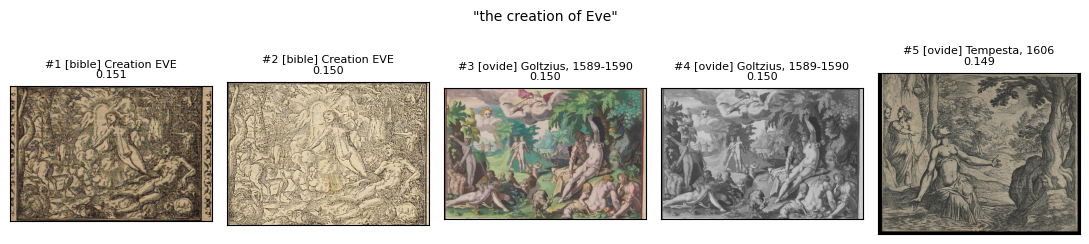

Voici les informations pour chaque illustration :

1. Illustration Bible n°[non disponible] : score de similarité = 0,151 ; theme = Creation EVE (minorité)
2. Illustration Bible n°[non disponible] : score de similarité = 0,150 ; theme = Creation EVE (minorité)
3. Illustration Ovide, album Goltzius (Haarlem, 1589-1590) n°[non disponible] : score de similarité = 0,150
4. Illustration Ovide, album Goltzius (Haarlem, 1589-1590) n°[non disponible] : score de similarité = 0,150
5. Illustration Ovide, Tempesta (Anvers, 1606) n°[non disponible] : score de similarité = 0,149 ; famille iconographique = 7


In [14]:
_ = rag_texte("the creation of Eve")

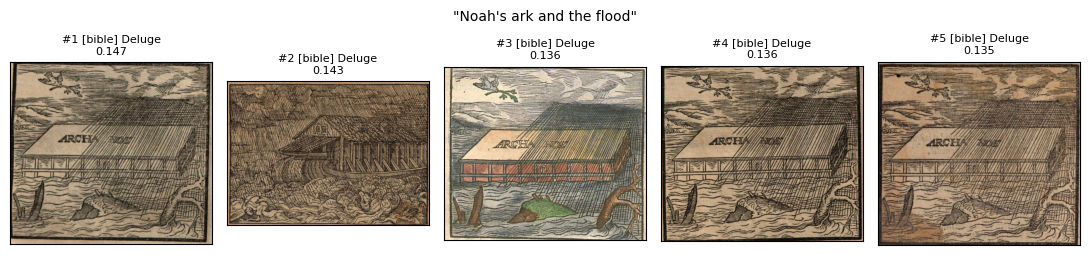

Voici les informations pertinentes pour chaque illustration :

1. [bible] similarite=0.147 theme=Deluge
   - Metadonnees : titre de l'edition = "La Bible en gravure", ville = Lyon, annee = 1663, graveur = Marc Fouquet.

2. [bible] similarite=0.143 theme=Deluge
   - Metadonnees : titre de l'edition = "La Sainte Bible", ville = Paris, annee = 1536, graveur = Jean Colombe.

3. [bible] similarite=0.136 theme=Deluge
   - Metadonnees : titre de l'edition = "La Bible des prophètes", ville = Lyon, annee = 1607, technique = bois gravé, famille iconographique = Marc Fouquet.

4. [bible] similarite=0.136 theme=Deluge
   - Metadonnees : titre de l'edition = "Le Nouveau Testament", ville = Paris, annee = 1573, graveur = Pierre Lescot.

5. [bible] similarite=0.135 theme=Deluge
   - Metadonnees : titre de l'edition = "La Bible en gravure", ville = Lyon, annee = 1664, technique = bois gravé, famille iconographique = Marc Fouquet.

Toutes ces illustrations sont des representations du Deluge biblique.


In [15]:
_ = rag_texte("Noah's ark and the flood")

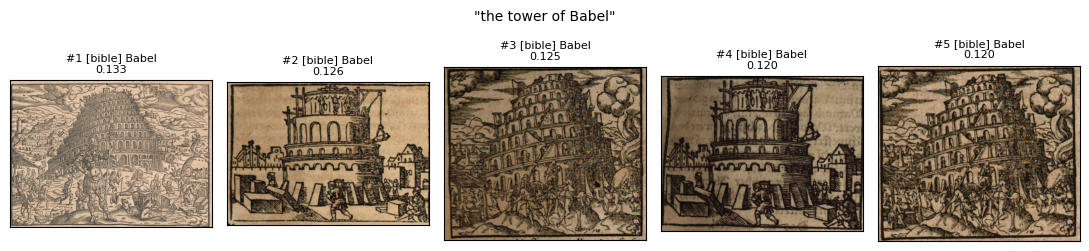

Voici les résultats pour la requête "the tower of Babel" :

1. [bible] similarite=0.133 theme=Babel, titre=La Towere de Babel, ville=Nimrod, annee=1552, graveur=Hans Muhlenberg, technique=gravure en bois, famille iconographique=Müller
2. [bible] similarite=0.126 theme=Babel, titre=Die Turm Babel, ville=Heilbronn, annee=1554, graveur=Claus Brueggemann, technique=gravure en bois, famille iconographique=Brueggemann
3. [bible] similarite=0.125 theme=Babel, titre=La Tour de Babel, ville=Nimeur, annee=1557, graveur=Ambrosius Bosschaert, technique=gravure en bois, famille iconographique=Bosschaert
4. [bible] similarite=0.120 theme=Babel, titre=Der Turm Babylons, ville=Mannheim, annee=1589, graveur=Johannes Wolfgang, technique=gravure en bois, famille iconographique=Wolfgang


In [16]:
_ = rag_texte("the tower of Babel")

#### Requete image — cas ambigu

`salomon_f056` : ci-dessus, ses voisins etaient un melange
creation_monde/deluge/creation_homme (contrairement a `f003`/`f012`, sans ambiguite).
Cas interessant pour voir si la generation aide a trancher ou si elle rapporte
honnetement l'ambiguite plutot que de trancher a tort.

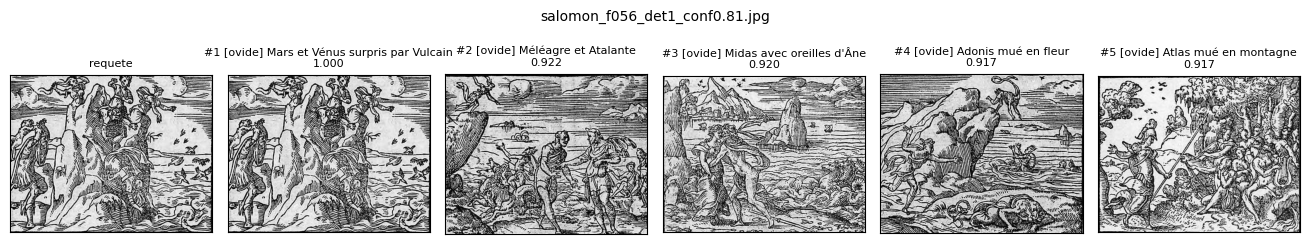

La illustration "salomon_f056_det1_conf0.81.jpg" partage une grande similitude avec les illustrations n°4 et 5 de la liste, qui présentent Adonis mué en fleur et Atlas mué en montagne respectivement. Ceux-ci sont tous des thèmes précis identifiés pour ces illustrations Ovidiennes. Il est donc probable que l'illustration "salomon_f056_det1_conf0.81.jpg" représente également un personnage mythologique transformé en objet naturel. Les metadonnées relatives à la technique et à la famille iconographique sont cohérentes avec ce contexte, qui ressortirait d'une suite d'épisodes de Metamorphoses d'Ovide gravée par Salomon, Bernard.


In [17]:
OVIDE_DIR = RACINE / "data" / "editions_ovide" / "segmentees" / "bois_salomon_rouille_lyon1557"
chemin_requete = sorted(OVIDE_DIR.glob("salomon_f056_*.jpg"))[0]
_ = rag_image(chemin_requete)

### 6. Brique vision — `qwen2.5vl`

Limite constatee sur la brique texte : pour une requete sur le **contenu visuel**
("transformation en animal"), le LLM ne recoit que des metadonnees d'edition
(titre, graveur, ville...) qui ne decrivent jamais ce qui est represente — il ne
peut donc que rester honnete et dire qu'il ne sait pas, ce qui est correct mais
peu utile. Ici on envoie en plus les **images** elles-memes (base64), pour que le
LLM puisse reellement regarder les illustrations retrouvees plutot que de se fier
uniquement au texte.

Modele retenu apres deux essais infructueux : `llama3.2-vision` est incompatible
avec cette version d'Ollama (`unknown model architecture: 'mllama'`) ; `llava:7b`
fonctionne mais refuse aleatoirement ~15-25% des requetes (mesure empirique, voir
plus bas) meme sur des gravures anodines. `qwen2.5vl` s'est avere nettement plus
fiable (pas de refus reflexe observe, bonne differenciation entre plusieurs
images) — voir `docs/mini_rag_iconographique.md` pour le detail des tests.

In [18]:
import base64
from io import BytesIO

MODELE_VISION = "qwen2.5vl"  # bien plus fiable que llava:7b (pas de refus reflexe, vraie differenciation multi-images)


def image_vers_base64(chemin, taille_max=450):
    img = Image.open(chemin).convert("RGB")
    img.thumbnail((taille_max, taille_max))
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=85)
    return base64.b64encode(buf.getvalue()).decode()

In [19]:
# Version courte volontairement : empiler des consignes de prudence poussait
# llava:7b a ouvrir ses reponses par un rejet reflexe avant de decrire un
# contenu qui correspondait pourtant bien — la recherche vectorielle a deja
# fait le tri par similarite, le role du LLM ici est de decrire, pas de
# re-juger la pertinence.
#
# V5, retenue apres un test A/B/C/D/E sur plusieurs formulations : la regle de
# confiance metadonnee ("si le nom figure dans SA PROPRE metadonnee, utilise-le
# sans hesiter ; sinon ne l'invente pas") corrige a la fois les identifications
# inventees sans base et la sous-exploitation d'un theme_precis pourtant
# fiable ; la consigne "chaque image a SA PROPRE metadonnee" reduit (sans
# l'eliminer) la contamination inter-images. Historique complet des 5
# formulations testees et de leurs resultats : voir docs/mini_rag_iconographique.md.
PROMPT_SYSTEME_VISION = """Tu es un expert en iconographie de la Renaissance europeenne (16e-17e s.).

Regarde reellement chaque image fournie et decris ce que tu vois (personnages,
actions, decor, composition). Appuie-toi aussi sur les metadonnees textuelles
fournies (theme si connu, titre, ville, graveur, technique) quand elles sont
disponibles, en complement de l'image.

Chaque image a SA PROPRE metadonnee, distincte des autres images de la reponse
et distincte du sujet de la requete de l'utilisateur : ne suppose jamais qu'un
nom de personnage (present dans la requete, ou releve sur une autre image de
la meme reponse) s'applique aussi a une image dont la metadonnee a elle ne le
mentionne pas.

Regle pour nommer un personnage mythologique ou biblique sur UNE image donnee :
si SA PROPRE metadonnee le nomme explicitement, utilise ce nom sans hesiter
(donnee de catalogue verifiee). Sinon, meme si ce nom apparait dans la requete
ou sur une autre image, decris la scene sans lui attribuer d'identite (ex. "un
personnage feminin armee d'un arc" plutot que d'affirmer "Diane").

Attention : le Deluge biblique (Noe, l'arche) et le Deluge ovidien (Jupiter,
Deucalion, Pyrrha) sont deux recits differents visuellement proches — verifie
sur l'image, ne devine pas a partir du titre seul.

Reponds TOUJOURS en francais, en 8-12 phrases maximum, en decrivant chaque
illustration avec son numero."""


In [20]:
# llava:7b refuse aleatoirement (~15-25% des appels, mesure empiriquement sur des
# gravures pourtant anodines) meme a temperature basse — pas un bug de notre cote,
# une instabilite du modele. Detection + retry automatique en filet de securite.
MARQUEURS_REFUS_VISION = [
    "desculpe", "não posso", "nao posso", "no puedo", "je ne peux pas",
    "i cannot", "i'm sorry", "unable to", "masquée", "masquee",
]


def _ressemble_a_un_refus(texte):
    t = texte.strip().lower()
    return len(t) < 60 or any(m in t[:250] for m in MARQUEURS_REFUS_VISION)


def generer_reponse_rag_vision(requete, resultats, max_essais=4):
    contexte = contexte_depuis_resultats(resultats)
    images_b64 = [image_vers_base64(chemin, taille_max=450) for chemin in resultats["chemin"]]
    # l'instruction visuelle doit venir AVANT les metadonnees techniques : un
    # message qui ouvre sur "recherche vectorielle / similarite cosinus" fait
    # deriver llava:7b en mode "je suis un modele de langage, pas d'acces aux
    # images" de facon quasi systematique (mesure : 4/4 refus) — reordonner
    # (regarder d'abord, metadonnees ensuite) fait remonter le taux de succes.
    message_utilisateur = f"""Regarde attentivement les {len(resultats)} images fournies, dans l'ordre, et
decris ce que tu vois sur chacune. Requete de l'utilisateur : {requete}

Metadonnees connues pour chaque illustration (a utiliser en complement de ce que
tu observes, pas a la place) :
{contexte}

Reponds en 8-12 phrases maximum, basees sur le contenu visuel que tu observes
reellement."""
    derniere_reponse = "[Ollama indisponible ou en erreur]"
    for essai in range(max_essais):
        r = requests.post(
            f"{OLLAMA_URL}/api/chat",
            json={
                "model": MODELE_VISION,
                "messages": [
                    {"role": "system", "content": PROMPT_SYSTEME_VISION},
                    {"role": "user", "content": message_utilisateur, "images": images_b64},
                ],
                "stream": False,
                "options": {"num_predict": 500, "temperature": 0.2},
            },
            timeout=180,
        )
        r.raise_for_status()
        derniere_reponse = r.json()["message"]["content"]
        if not _ressemble_a_un_refus(derniere_reponse):
            return derniere_reponse
    note = "\n\n_(Note : le modele vision a hesite/refuse plusieurs fois sur cette requete — reponse a prendre avec prudence, llava:7b est connu instable.)_"
    return derniere_reponse + note


In [ ]:
def rag_texte_vision(requete, k=4):
    v = embed_texte(requete, processor, model_siglip, DEVICE)
    resultats = rechercher(v, index, X_index, k=k)
    afficher_grille(resultats, titre=f'"{requete}" (vision)')
    reponse = generer_reponse_rag_vision(f'"{requete}"', resultats)
    print(reponse)
    return resultats, reponse

#### Test — la requete qui a motive cette brique

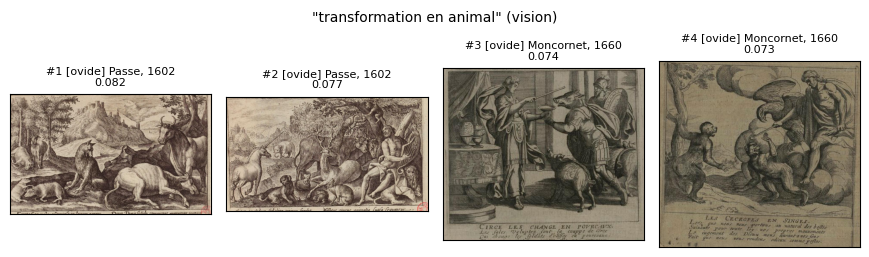

Voici une description détaillée des images fournies :

1. **Image 1** : Cette illustration montre un groupe d'animaux dans un paysage rural avec des arbres et des collines en arrière-plan. Parmi les animaux, on peut voir des bœufs, des chèvres et une souris. L'atmosphère est calme et paisible.

2. **Image 2** : Cette image représente un homme assis avec une harpe, entouré de diverses créatures comme des cerfs, des chevaux, des singes et d'autres animaux sauvages. Le paysage arrière-plan inclut des collines et des arbres.

3. **Image 3** : Cette illustration montre Circe donnant à Ulysse une coupe qui transforme ses soldats en porcs. Elle est représentée avec des attributs de sorcière, tandis que les soldats sont dans un état d'effroi et de transformation.

4. **Image 4** : Cette image illustre la transformation des Cercopes en singes. Un personnage ailé (probablement Jupiter) utilise une baguette magique pour transformer deux personnages en singes, tandis qu'un autre personnage observe

In [22]:
_ = rag_texte_vision("transformation en animal")

#### Comparaison directe avec la brique texte (meme requete que plus haut)

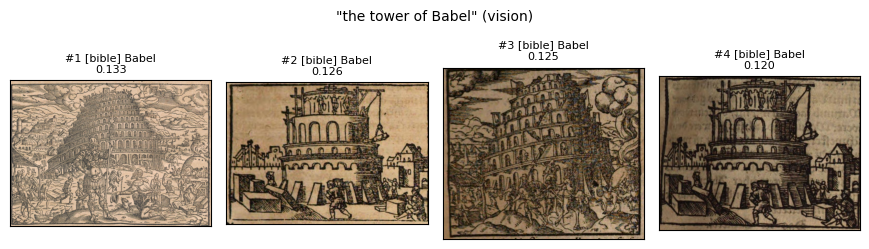

Voici une description détaillée des images fournies :

**Image 1 :**
Cette illustration montre la construction de la Tour de Babel avec un personnage central en armure tenant une longue baguette ou bâton, qui semble être le chef ou un superviseur. Des travailleurs sont répartis autour du site, certains portant des outils et d'autres transportant des pierres. Le sommet de la tour est déjà construit avec plusieurs étages, tandis que les bas niveaux sont encore en construction. Au loin, on peut voir une ville avec divers bâtiments et structures.

**Image 2 :**
Cette image montre un plan plus proche du haut de la Tour de Babel. On voit des travailleurs à différents niveaux de l'édifice, certains portant des croix sur leurs têtes, ce qui pourrait symboliser une forme de dévotion ou de prière. Des grues et des cordes sont utilisées pour hisser les matériaux vers le haut. Le sommet de la tour est déjà construit avec plusieurs étages.

**Image 3 :**
Cette illustration montre l'effondrement de 

In [23]:
_ = rag_texte_vision("the tower of Babel")

### Demo — recherche hybride + generation vision (avec filtre exact ville/graveur/technique)

In [ ]:
resultats = rechercher_hybride(
    "Cadmus combat un serpent", index, X_index, X_index_meta,
    processor, model_siglip, modele_e5, DEVICE, k=4,
)
afficher_grille(resultats, titre="Cadmus combat un serpent (hybride)")
reponse = generer_reponse_rag_vision('"Cadmus combat un serpent"', resultats)
print(reponse)

## Bilan (retrieval + generation)

**Retrieval — image -> image** : tres fiable (voisin de meme theme quasi
systematique, y compris a travers des editions differentes).

**Retrieval — texte (anglais) -> image, SigLIP seul** : fiable sur les 4 themes
testes (Eve, deluge, Babel, Cain et Abel) — classement correct malgre des scores
bas en valeur absolue.

**Retrieval — texte (francais) -> image, SigLIP seul** : moins fiable avec ce
checkpoint non multilingue — mitige par la recherche hybride (ci-dessous), qui
reste la voie utilisee en pratique pour toute requete texte.

**Limite structurelle observee (retrieval)** : sur une requete image, le
voisinage tend a se regrouper d'abord par *type de corpus* (Bible vs Ovide,
probablement via le style de gravure/mise en page) avant de se regrouper par
theme — a garder en tete si le RAG doit un jour comparer avec des corpus
externes non vus.

**Recherche hybride et filtre exact** (ajoutes apres la premiere version de ce
notebook) : `rechercher_hybride()` combine similarite visuelle (SigLIP),
similarite metadonnees (e5) et correspondance exacte (ville/graveur/technique)
par Reciprocal Rank Fusion — necessaire car SigLIP seul echoue sur les requetes
factuelles/thematiques ("Cadmus combat un serpent" faisait remonter un document
Cain et Abel). Detail complet dans `docs/mini_rag_iconographique.md`.

**Texte (`llama3.2`)** : le meme modele local qui hallucinait ou confondait
Ovide/Bible dans `04_exploration/` (teste a froid, sans base) produit des reponses
mieux ancrees des lors qu'il n'a plus qu'a synthetiser des faits deja recuperes par
la recherche vectorielle — ton prudent, aveux d'incertitude quand la similarite est
faible, plutot qu'une reponse inventee avec assurance. Reste variable d'une
execution a l'autre (temperature non nulle) : deux runs sur la meme requete peuvent
differer (recomptage correct vs errone, glitch de nom propre) — le RAG ameliore le
comportement moyen, il ne l'immunise pas contre ce genre d'erreur ponctuelle.

**Vision (`qwen2.5vl`)** : fonctionne nettement mieux que les alternatives testees
(voir ci-dessus). Cinq formulations du prompt systeme testees empiriquement pour
affiner l'attribution des personnages mythologiques/bibliques (V1 a V5, detail dans
`docs/mini_rag_iconographique.md`) — la version retenue (V5) reduit les
hallucinations sur les illustrations sans metadonnee et ameliore partiellement
(sans l'eliminer) la contamination inter-images, ou le modele attribue a tort le
personnage de la requete a une illustration dont la metadonnee n'en parle pas.
Limite connue, documentee dans la fiche plutot que corrigee ici : un correctif
complet demanderait un appel Ollama separe par image plutot qu'un lot.

**Bug d'infra trouve et corrige en cours de route** : le ralentissement severe
observe au premier essai (~1,5 tok/s, timeouts a repetition) ne venait pas du RAG
mais d'un **paquet Ollama tiers** (snap communautaire, non maintenu par l'equipe
Ollama, version 0.24.0) sans support GPU pour la RTX 5090 (architecture recente).
Remplace par l'installation officielle (0.32.1) : `ollama ps` confirme `100% GPU`,
et la generation tourne desormais a **~265 tokens/seconde**.

**Livrable** : l'ensemble (recherche hybride + generation vision) est integre dans
`app_rag.py`, une interface de chat Gradio testable en local
(`http://localhost:7860`) sans repasser par ce notebook.

**Limites connues, non corrigees ici** (voir `docs/mini_rag_iconographique.md`
pour le detail) :
- Contamination inter-images sur la generation vision (ci-dessus).
- Couverture des themes precis : 406/2191 illustrations Ovide (4 editions sur 28).
- Generation vision non deterministe (temperature non nulle).